<a href="https://colab.research.google.com/github/MuhammadSaad993/Final-Year-Project-Saad-/blob/main/Diabetes_Prediction_ML_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Loading Dataset**

In [1]:
pip install ucimlrepo

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
cdc_diabetes_health_indicators = fetch_ucirepo(id=891)

# data (as pandas dataframes)
X = cdc_diabetes_health_indicators.data.features
y = cdc_diabetes_health_indicators.data.targets

# metadata
print(cdc_diabetes_health_indicators.metadata)

# variable information
print(cdc_diabetes_health_indicators.variables)


{'uci_id': 891, 'name': 'CDC Diabetes Health Indicators', 'repository_url': 'https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators', 'data_url': 'https://archive.ics.uci.edu/static/public/891/data.csv', 'abstract': 'The Diabetes Health Indicators Dataset contains healthcare statistics and lifestyle survey information about people in general along with their diagnosis of diabetes. The 35 features consist of some demographics, lab test results, and answers to survey questions for each patient. The target variable for classification is whether a patient has diabetes, is pre-diabetic, or healthy. ', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Tabular', 'Multivariate'], 'num_instances': 253680, 'num_features': 21, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Sex', 'Age', 'Education Level', 'Income'], 'target_col': ['Diabetes_binary'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_

# **Exploratory Data Analysis**

## **Printing basic Dataset**

In [4]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

# Fetch dataset
cdc_diabetes_health_indicators = fetch_ucirepo(id=891)

# Convert features and targets to a single unified DataFrame
X = cdc_diabetes_health_indicators.data.features
y = cdc_diabetes_health_indicators.data.targets

df = pd.concat([X, y], axis=1)

# Verify the conversion
print(f"Dataset Shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())

Dataset Shape: (253680, 22)

First 5 rows:
   HighBP  HighChol  CholCheck  BMI  Smoker  Stroke  HeartDiseaseorAttack  \
0       1         1          1   40       1       0                     0   
1       0         0          0   25       1       0                     0   
2       1         1          1   28       0       0                     0   
3       1         0          1   27       0       0                     0   
4       1         1          1   24       0       0                     0   

   PhysActivity  Fruits  Veggies  ...  NoDocbcCost  GenHlth  MentHlth  \
0             0       0        1  ...            0        5        18   
1             1       0        0  ...            1        3         0   
2             0       1        0  ...            1        5        30   
3             1       1        1  ...            0        2         0   
4             1       1        1  ...            0        2         3   

   PhysHlth  DiffWalk  Sex  Age  Education  Income  Dia

## **Check Missingness**

In [5]:

print("Checking for missing values per feature:")
missing_summary = df.isnull().sum().to_frame(name="Missing Counts")
missing_summary["Percentage (%)"] = (df.isnull().sum() / len(df)) * 100

print(missing_summary)

# Assert check to verify clean data structure
if df.isnull().sum().sum() == 0:
    print("\nNo missing values found. Dataset is completely clean.")
else:
    print(f"\nWarning: Found {df.isnull().sum().sum()} missing entries.")

Checking for missing values per feature:
                      Missing Counts  Percentage (%)
HighBP                             0             0.0
HighChol                           0             0.0
CholCheck                          0             0.0
BMI                                0             0.0
Smoker                             0             0.0
Stroke                             0             0.0
HeartDiseaseorAttack               0             0.0
PhysActivity                       0             0.0
Fruits                             0             0.0
Veggies                            0             0.0
HvyAlcoholConsump                  0             0.0
AnyHealthcare                      0             0.0
NoDocbcCost                        0             0.0
GenHlth                            0             0.0
MentHlth                           0             0.0
PhysHlth                           0             0.0
DiffWalk                           0             0.0
Sex  

## **TARGET VARIABLE DISTRIBUTION**

Target Variable Distribution Breakdown:
Class 0 (Healthy): 218334 entries (86.07%)
Class 1 (Diabetic/Prediabetic): 35346 entries (13.93%)


/tmp/ipykernel_810/1169593856.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


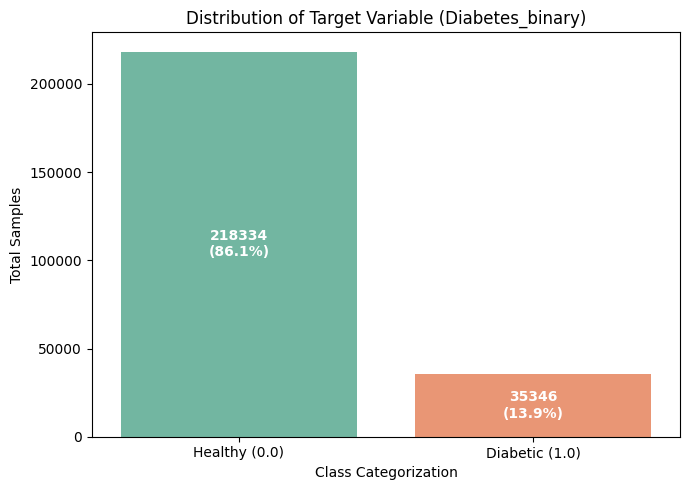

Saved visualization as 'target_distribution.png'


In [6]:

target_counts = df['Diabetes_binary'].value_counts()
target_proportions = df['Diabetes_binary'].value_counts(normalize=True) * 100

print("Target Variable Distribution Breakdown:")
for cls, count in target_counts.items():
    label = "Diabetic/Prediabetic" if cls == 1.0 else "Healthy"
    print(f"Class {int(cls)} ({label}): {count} entries ({target_proportions[cls]:.2f}%)")

# Visualization
plt.figure(figsize=(7, 5))
ax = sns.barplot(
    x=target_counts.index.map({0.0: 'Healthy (0.0)', 1.0: 'Diabetic (1.0)'}),
    y=target_counts.values,
    palette='Set2'
)

# Annotate bars with counts and percentages
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}\n({height/len(df)*100:.1f}%)',
                (p.get_x() + p.get_width() / 2., height / 2),
                ha='center', va='center', color='white', fontweight='bold')

plt.title('Distribution of Target Variable (Diabetes_binary)')
plt.ylabel('Total Samples')
plt.xlabel('Class Categorization')
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150)
plt.show()
print("Saved visualization as 'target_distribution.png'")

## **BOX PLOTS FOR CONTINUOUS FEATURES**

/tmp/ipykernel_810/1835920661.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df['BMI'], x=df['Diabetes_binary'].map({0.0: 'Healthy', 1.0: 'Diabetic'}), ax=axes[0], palette='pastel')
/tmp/ipykernel_810/1835920661.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df['MentHlth'], x=df['Diabetes_binary'].map({0.0: 'Healthy', 1.0: 'Diabetic'}), ax=axes[1], palette='pastel')
/tmp/ipykernel_810/1835920661.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df['PhysHlth'], x=df['Diabetes_binary'].map({0.0: 'Healthy', 1.0: 'Diabetic'})

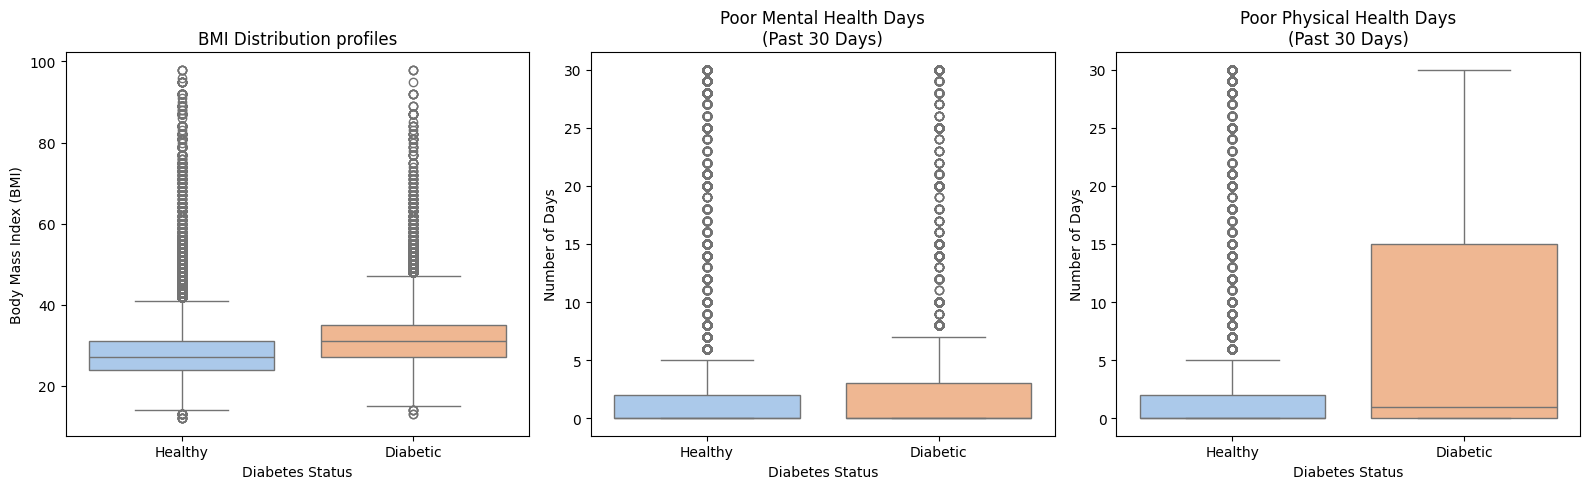

Saved visualization as 'box_plots.png'


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: BMI Distribution
sns.boxplot(y=df['BMI'], x=df['Diabetes_binary'].map({0.0: 'Healthy', 1.0: 'Diabetic'}), ax=axes[0], palette='pastel')
axes[0].set_title('BMI Distribution profiles')
axes[0].set_xlabel('Diabetes Status')
axes[0].set_ylabel('Body Mass Index (BMI)')

# Plot 2: Mental Health Distribution
sns.boxplot(y=df['MentHlth'], x=df['Diabetes_binary'].map({0.0: 'Healthy', 1.0: 'Diabetic'}), ax=axes[1], palette='pastel')
axes[1].set_title('Poor Mental Health Days\n(Past 30 Days)')
axes[1].set_xlabel('Diabetes Status')
axes[1].set_ylabel('Number of Days')

# Plot 3: Physical Health Distribution
sns.boxplot(y=df['PhysHlth'], x=df['Diabetes_binary'].map({0.0: 'Healthy', 1.0: 'Diabetic'}), ax=axes[2], palette='pastel')
axes[2].set_title('Poor Physical Health Days\n(Past 30 Days)')
axes[2].set_xlabel('Diabetes Status')
axes[2].set_ylabel('Number of Days')

plt.tight_layout()
plt.savefig('box_plots.png', dpi=150)
plt.show()
print("Saved visualization as 'box_plots.png'")

## **FREQUENCY DISTRIBUTIONS**

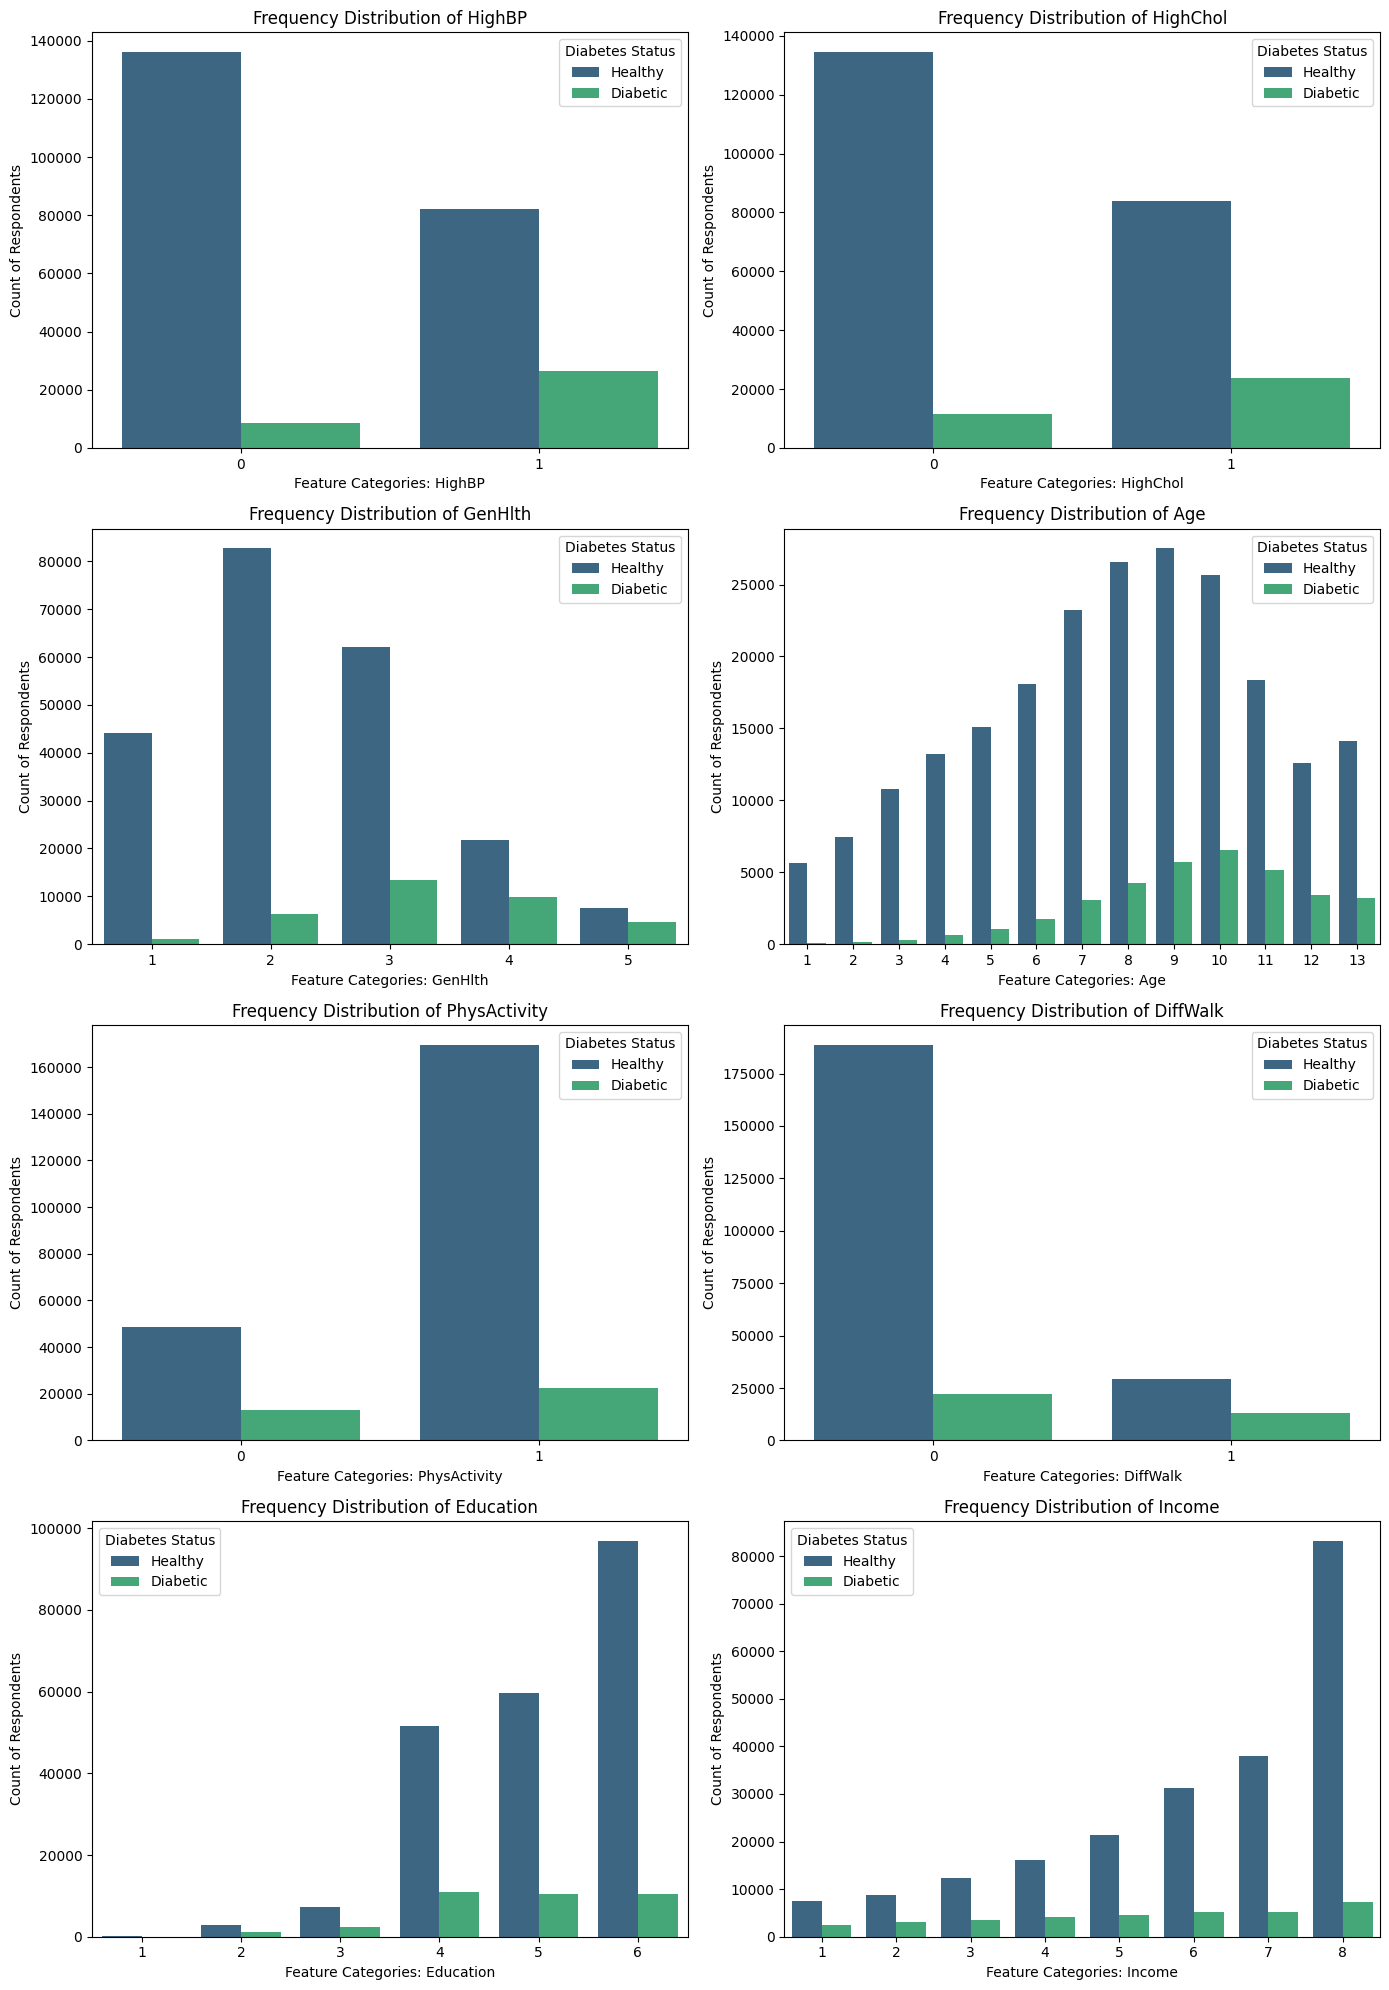

Saved visualization as 'frequency_distributions.png'


In [8]:
features_to_plot = ['HighBP', 'HighChol', 'GenHlth', 'Age', 'PhysActivity', 'DiffWalk', 'Education', 'Income']

fig, axes = plt.subplots(4, 2, figsize=(14, 20))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    sns.countplot(data=df, x=col, hue='Diabetes_binary', ax=axes[i], palette='viridis')
    axes[i].set_title(f'Frequency Distribution of {col}')
    axes[i].set_xlabel(f'Feature Categories: {col}')
    axes[i].set_ylabel('Count of Respondents')
    axes[i].legend(title='Diabetes Status', labels=['Healthy', 'Diabetic'])

plt.tight_layout()
plt.savefig('frequency_distributions.png', dpi=150)
plt.show()
print("Saved visualization as 'frequency_distributions.png'")

## **CORRELATION HEATMAP ANALYSIS**

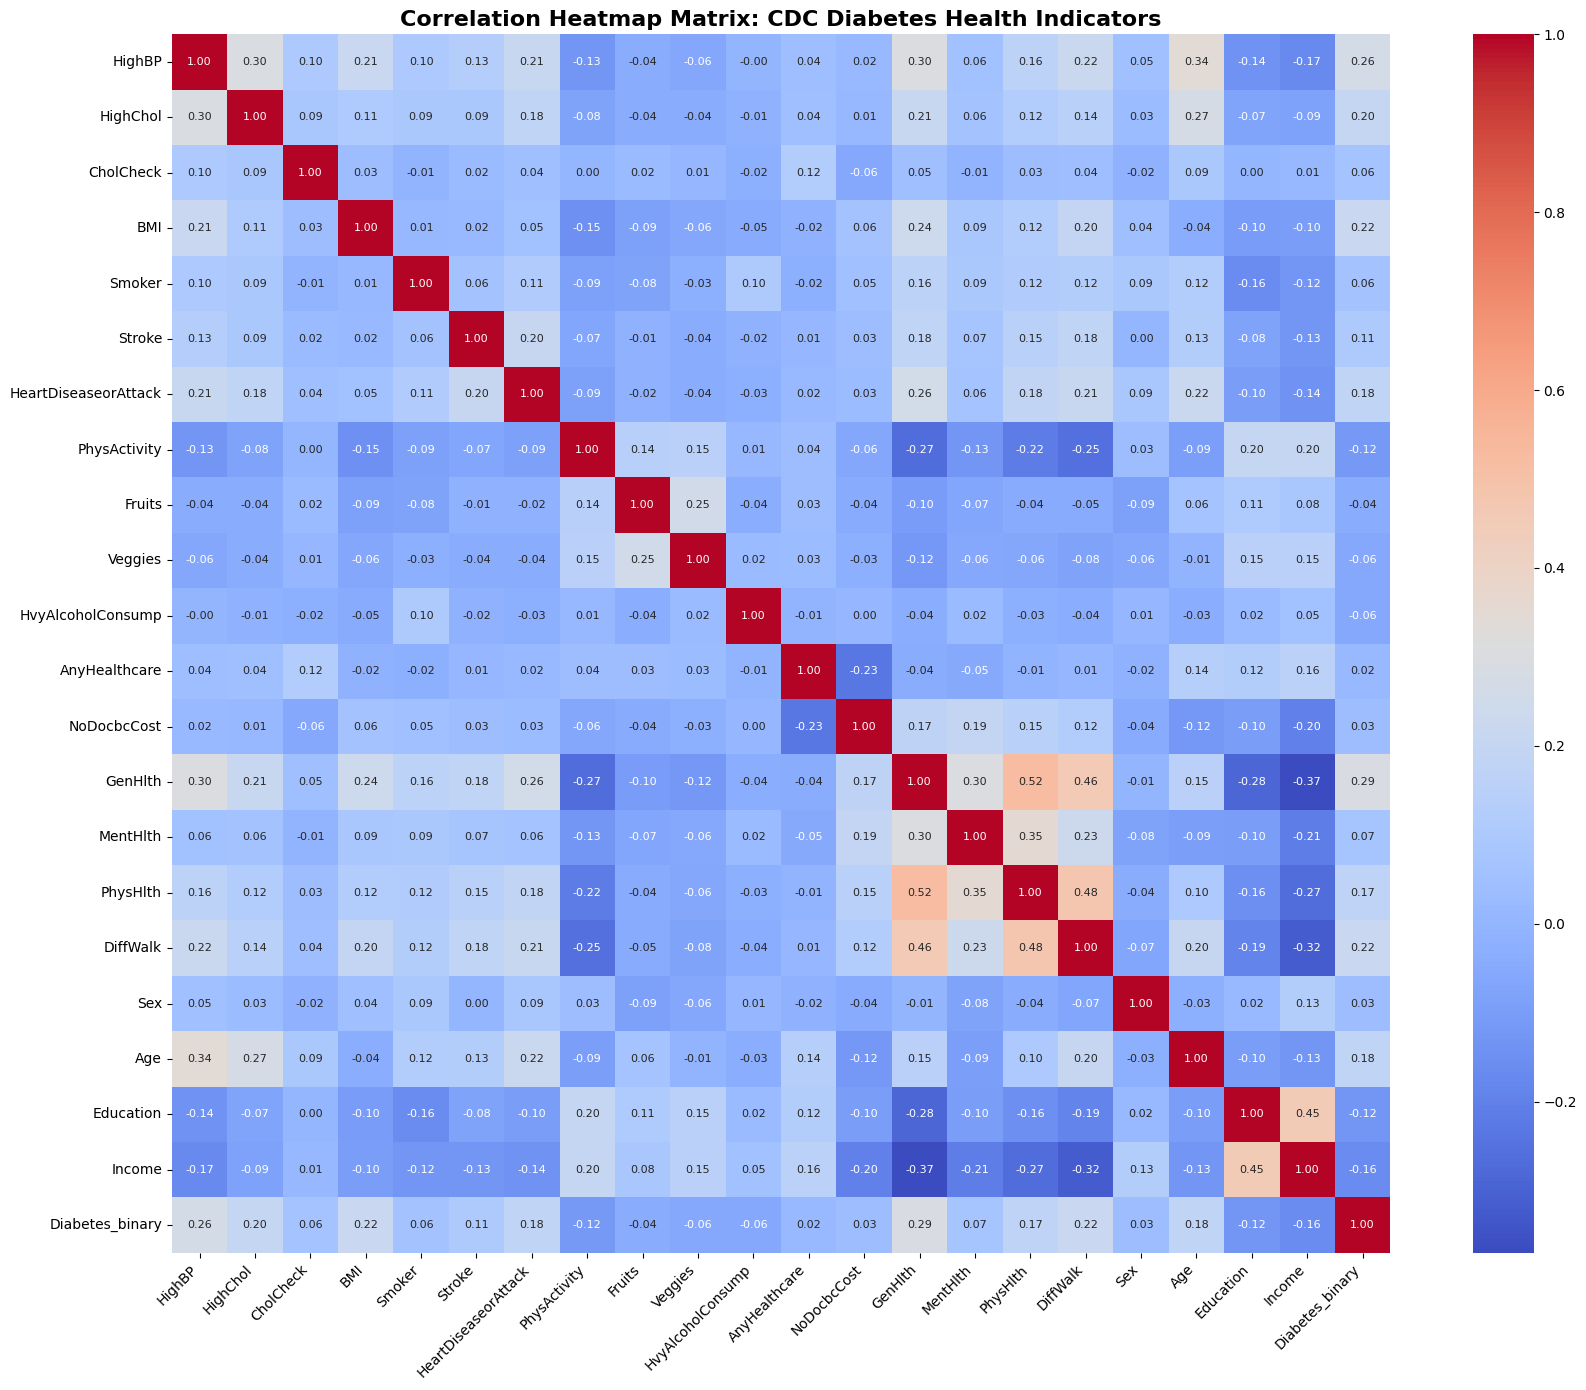

Saved visualization as 'correlation_heatmap.png'

Ranked Linear Correlation Coefficients with 'Diabetes_binary':
Diabetes_binary         1.000000
GenHlth                 0.293569
HighBP                  0.263129
DiffWalk                0.218344
BMI                     0.216843
HighChol                0.200276
Age                     0.177442
HeartDiseaseorAttack    0.177282
PhysHlth                0.171337
Stroke                  0.105816
MentHlth                0.069315
CholCheck               0.064761
Smoker                  0.060789
NoDocbcCost             0.031433
Sex                     0.031430
AnyHealthcare           0.016255
Fruits                 -0.040779
Veggies                -0.056584
HvyAlcoholConsump      -0.057056
PhysActivity           -0.118133
Education              -0.124456
Income                 -0.163919
Name: Diabetes_binary, dtype: float64


In [9]:
corr_matrix = df.corr()

# Plot the comprehensive heatmap Matrix
plt.figure(figsize=(18, 14))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar=True,
    square=True,
    annot_kws={"size": 8}
)
plt.title('Correlation Heatmap Matrix: CDC Diabetes Health Indicators', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()
print("Saved visualization as 'correlation_heatmap.png'\n")

# Display ranked correlation coefficients purely relative to the target
print("Ranked Linear Correlation Coefficients with 'Diabetes_binary':")
print(corr_matrix['Diabetes_binary'].sort_values(ascending=False))

# **DATA PREPROCESSING & CLASS BALANCING PIPELINE**

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.combine import SMOTEENN

# 1. Stratified Subsampling (To make SVM training computationally feasible)
class_proportions = df['Diabetes_binary'].value_counts(normalize=True)

total_samples = 20000
samples_class_0 = int(total_samples * class_proportions[0])
samples_class_1 = int(total_samples * class_proportions[1])

df_class_0 = df[df['Diabetes_binary'] == 0].sample(n=samples_class_0, random_state=42)
df_class_1 = df[df['Diabetes_binary'] == 1].sample(n=samples_class_1, random_state=42)
df_subsampled = pd.concat([df_class_0, df_class_1]).sample(frac=1, random_state=42).reset_index(drop=True)

X_raw = df_subsampled.drop(columns=['Diabetes_binary'])
y_raw = df_subsampled['Diabetes_binary']


# 2. Step 1 of Split: Isolate the Pure Test Set (15%)
# This ensures our final test data remains completely unmanipulated by resampling
X_train_val_raw, X_test, y_train_val_raw, y_test = train_test_split(
    X_raw, y_raw, test_size=0.15, stratify=y_raw, random_state=42
)


# 3. Class Balancing (Applied to Train/Val pool before final training splits)
print("Applying SMOTE+ENN Class Balancing to the Training/Validation pool...")
sme = SMOTEENN(random_state=42)
X_balanced, y_balanced = sme.fit_resample(X_train_val_raw, y_train_val_raw)


# 4. Step 2 of Split: Separate Train and Validation from Balanced Pool
# Splitting the balanced pool into 82.35% training and 17.65% validation
# to maintain the original 70%/15% ratio breakdown of the master pool
X_train, X_val, y_train, y_val = train_test_split(
    X_balanced, y_balanced, test_size=0.1765, stratify=y_balanced, random_state=42
)

print(f"\nData Distribution Profiles Post-Balancing:")
print(f"--> Training Set Shape   : {X_train.shape} (Diabetes Rate: {y_train.mean()*100:.2f}%)")
print(f"--> Validation Set Shape : {X_val.shape} (Diabetes Rate: {y_val.mean()*100:.2f}%)")
print(f"--> Pure Test Set Shape  : {X_test.shape} (Diabetes Rate: {y_test.mean()*100:.2f}%)")


# 5. Leak-Free Feature Scaling
# Fitting ONLY on X_train to keep the scaling parameters isolated
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Transforming Validation and Test sets using the training parameters
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("\nBlock 8: Preprocessing and balancing pipeline completed successfully.")

Applying SMOTE+ENN Class Balancing to the Training/Validation pool...

Data Distribution Profiles Post-Balancing:
--> Training Set Shape   : (17468, 21) (Diabetes Rate: 62.32%)
--> Validation Set Shape : (3744, 21) (Diabetes Rate: 62.31%)
--> Pure Test Set Shape  : (3000, 21) (Diabetes Rate: 13.93%)

Block 8: Preprocessing and balancing pipeline completed successfully.


# **MODEL INITIALIZATION & TRAINING**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import time

# Calculate scale_pos_weight for XGBoost imbalance correction
num_neg = (y_train == 0).sum()
num_pos = (y_train == 1).sum()
xgboost_imbalance_ratio = num_neg / num_pos

print("Initializing models with class-imbalance correction strategies...")

# 1. Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# 2. XGBoost Classifier
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=xgboost_imbalance_ratio,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

# 3. Support Vector Machine (SVM) Classifier
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    class_weight='balanced',
    probability=True,  # Required to compute AUC and PR-AUC scores later
    random_state=42
)

# --- Model Execution / Fitting ---

# Train Random Forest
print("\nTraining Random Forest Classifier...")
start_time = time.time()
rf_model.fit(X_train, y_train)  # Tree models don't strictly require scaled data
print(f"--> RF Training completed in {time.time() - start_time:.2f} seconds.")

# Train XGBoost
print("Training XGBoost Classifier...")
start_time = time.time()
xgb_model.fit(X_train, y_train) # Tree models don't strictly require scaled data
print(f"--> XGBoost Training completed in {time.time() - start_time:.2f} seconds.")

# Train SVM
print("Training Support Vector Machine (Requires Scaled Inputs)...")
start_time = time.time()
svm_model.fit(X_train_scaled, y_train) # SVM requires scaled data to compute margins accurately
print(f"--> SVM Training completed in {time.time() - start_time:.2f} seconds.")

print("\nBlock 9: Architectural models trained successfully.")

Initializing models with class-imbalance correction strategies...

Training Random Forest Classifier...
--> RF Training completed in 3.09 seconds.
Training XGBoost Classifier...
--> XGBoost Training completed in 0.49 seconds.
Training Support Vector Machine (Requires Scaled Inputs)...


## **Model Evaluationst**

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, precision_recall_curve, auc,
    confusion_matrix, roc_curve, ConfusionMatrixDisplay
)

def evaluate_and_plot_models(models_dict, X_test_dict, y_true):
    """
    Evaluates multiple models, prints a comparative metrics DataFrame,
    and plots paired Confusion Matrices and ROC Curves.

    models_dict: dict of {'Model Name': model_object}
    X_test_dict: dict of {'Model Name': X_data_for_that_model} (handles scaled/unscaled data)
    y_true: Ground truth target array
    """
    results = {}
    plt.figure(figsize=(15, 5 * len(models_dict)))

    # Initialize a master plot for combined ROC Curves
    fig_roc, ax_roc = plt.subplots(figsize=(8, 6))
    ax_roc.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.50)')

    # Prepare grid plot for individual Confusion Matrices
    fig_cm, axes_cm = plt.subplots(1, len(models_dict), figsize=(5 * len(models_dict), 4.5))
    if len(models_dict) == 1:
        axes_cm = [axes_cm]

    for idx, (name, model) in enumerate(models_dict.items()):
        X_data = X_test_dict[name]

        # 1. Predictions and Probabilities
        preds = model.predict(X_data)
        probs = model.predict_proba(X_data)[:, 1]

        # 2. Calculate Scalar Metrics
        acc = accuracy_score(y_true, preds)
        prec = precision_score(y_true, preds)
        rec = recall_score(y_true, preds)
        f1 = f1_score(y_true, preds)
        roc_auc = roc_auc_score(y_true, probs)

        precision_vals, recall_vals, _ = precision_recall_curve(y_true, probs)
        pr_auc = auc(recall_vals, precision_vals)

        # Save metrics to our dictionary
        results[name] = [acc, prec, rec, f1, roc_auc, pr_auc]

        # 3. Compute and Plot Confusion Matrix
        cm = confusion_matrix(y_true, preds)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy', 'Diabetic'])
        disp.plot(ax=axes_cm[idx], cmap='Blues', colorbar=False)
        axes_cm[idx].set_title(f'Confusion Matrix:\n{name}')
        axes_cm[idx].grid(False) # Clean up gridlines for presentation

        # 4. Compute and Plot ROC Curve onto the shared canvas
        fpr, tpr, _ = roc_curve(y_true, probs)
        ax_roc.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

    # Finalize Confusion Matrix Plot layout
    fig_cm.tight_layout()
    fig_cm.savefig('comparative_confusion_matrices.png', dpi=150)

    # Finalize ROC Curve Plot layout
    ax_roc.set_title('Receiver Operating Characteristic (ROC) Curves', fontsize=14, fontweight='bold')
    ax_roc.set_xlabel('False Positive Rate (1 - Specificity)')
    ax_roc.set_ylabel('True Positive Rate (Sensitivity)')
    ax_roc.legend(loc='lower right')
    fig_roc.tight_layout()
    fig_roc.savefig('comparative_roc_curves.png', dpi=150)

    plt.show()

    # 5. Compile Results into a pandas DataFrame
    metrics_columns = ['Accuracy', 'Precision', 'Recall (Sensitivity)', 'F1-Score', 'ROC-AUC', 'PR-AUC']
    df_metrics = pd.DataFrame.from_dict(results, orient='index', columns=metrics_columns)

    return df_metrics

# --- EXECUTION BLOCK ---

# Pack models and their corresponding correct data vectors (since SVM needs scaled features)
models = {
    'Random Forest': rf_model,
    'XGBoost': xgb_model,
    'Support Vector Machine': svm_model
}

X_validation_inputs = {
    'Random Forest': X_val,
    'XGBoost': X_val,
    'Support Vector Machine': X_val_scaled
}

print("Executing comprehensive evaluation metrics & visualization frameworks...\n")
report_df = evaluate_and_plot_models(models, X_validation_inputs, y_val)

# Display the final structured report table
print("\n=== Comparative Evaluation Summary (Validation Dataset) ===")
print(report_df.round(4))

# **ADVANCED FEATURE ENGINEERING & MODEL RETRAINING**

In [ ]:
import time
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, auc

# --- 1. DOMAIN-DRIVEN FEATURE ENGINEERING FUNCTION ---
def apply_feature_engineering(input_df):
    """
    Applies clinical and lifestyle interaction terms to the dataset
    to help models capture non-linear risk factors.
    """
    df_eng = input_df.copy()

    # Interaction 1: Metabolic Syndrome Proxy (High BP AND High Cholesterol)
    df_eng['Metabolic_Risk_Score'] = df_eng['HighBP'] * df_eng['HighChol']

    # Interaction 2: Sedentary Obesity Profile (BMI scaled by lack of physical activity)
    df_eng['Sedentary_Obesity_Index'] = df_eng['BMI'] * (1 - df_eng['PhysActivity'])

    # Interaction 3: Age-driven Health Decline Proxy
    df_eng['Age_Health_Interaction'] = df_eng['Age'] * df_eng['GenHlth']

    # Interaction 4: Socioeconomic Vulnerability Index (Combining low income & low education)
    # Mapping scales so that higher numbers mean higher risk/lower socioeconomic status
    df_eng['Socioeconomic_Risk'] = (7 - df_eng['Education']) * (9 - df_eng['Income'])

    return df_eng

# --- 2. APPLY TO SPLITS ---
# Transform raw feature matrices using the new engineering logic
X_train_eng = apply_feature_engineering(X_train)
X_val_eng = apply_feature_engineering(X_val)
X_test_eng = apply_feature_engineering(X_test)

print(f"Feature transformation complete:")
print(f"--> Original Feature Count : {X_train.shape[1]}")
print(f"--> Enhanced Feature Count : {X_train_eng.shape[1]}")

# --- 3. RE-SCALE THE ENHANCED FEATURES FOR SVM ---
scaler_eng = StandardScaler()
X_train_eng_scaled = scaler_eng.fit_transform(X_train_eng)
X_val_eng_scaled = scaler_eng.transform(X_val_eng)
X_test_eng_scaled = scaler_eng.transform(X_test_eng)

# --- 4. RE-INITIALIZE AND TRAIN THE ARCHITECTURES ---
num_neg = (y_train == 0).sum()
num_pos = (y_train == 1).sum()
xgb_ratio = num_neg / num_pos

rf_eng_model = RandomForestClassifier(n_estimators=200, max_depth=12, class_weight='balanced', random_state=42, n_jobs=-1)
xgb_eng_model = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, scale_pos_weight=xgb_ratio, random_state=42, eval_metric='logloss', n_jobs=-1)
svm_eng_model = SVC(kernel='rbf', C=1.0, class_weight='balanced', probability=True, random_state=42)

print("\nRetraining models with enhanced lifestyle interaction features...")

start = time.time()
rf_eng_model.fit(X_train_eng, y_train)
print(f"--> Random Forest completed in {time.time() - start:.2f}s")

start = time.time()
xgb_eng_model.fit(X_train_eng, y_train)
print(f"--> XGBoost completed in {time.time() - start:.2f}s")

start = time.time()
svm_eng_model.fit(X_train_eng_scaled, y_train)
print(f"--> SVM completed in {time.time() - start:.2f}s")

## **MODEL PERFORMANCE EVALUATION**

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, precision_recall_curve, auc,
    confusion_matrix, roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

def evaluate_engineered_pipeline(models_dict, X_val_dict, y_true):
    """
    Evaluates models trained on engineered features, prints structured reporting data,
    and visualizes performance metrics via ROC Curves and Confusion Matrices.
    """
    results = {}

    # 1. Initialize evaluation canvases for visualizations
    fig_roc, ax_roc = plt.subplots(figsize=(8, 6))
    ax_roc.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.50)')

    fig_cm, axes_cm = plt.subplots(1, len(models_dict), figsize=(5 * len(models_dict), 4.5))
    if len(models_dict) == 1:
        axes_cm = [axes_cm]

    # 2. Loop through each model for matrix compilation
    for idx, (name, model) in enumerate(models_dict.items()):
        X_data = X_val_dict[name]

        # Continuous risk probability vector extraction and class predictions
        # Note: Since data was structurally balanced in Block 8, standard 0.5 threshold is applied
        preds = model.predict(X_data)
        probs = model.predict_proba(X_data)[:, 1]

        # Calculate evaluation metrics
        acc = accuracy_score(y_true, preds)
        prec = precision_score(y_true, preds, zero_division=0)
        rec = recall_score(y_true, preds)
        f1 = f1_score(y_true, preds)
        roc_auc = roc_auc_score(y_true, probs)

        # Calculate Precision-Recall Area Under Curve (PR-AUC)
        precision_vals, recall_vals, _ = precision_recall_curve(y_true, probs)
        pr_auc = auc(recall_vals, precision_vals)

        # Store records
        results[name] = [acc, prec, rec, f1, roc_auc, pr_auc]

        # 3. Build Confusion Matrix Subplot
        cm = confusion_matrix(y_true, preds)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy', 'Diabetic'])
        disp.plot(ax=axes_cm[idx], cmap='Blues', colorbar=False)
        axes_cm[idx].set_title(f'Confusion Matrix:\n{name}')
        axes_cm[idx].grid(False)

        # 4. Build ROC Curve Plot
        fpr, tpr, _ = roc_curve(y_true, probs)
        ax_roc.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

    # Finalize visual structures
    fig_cm.tight_layout()
    fig_cm.savefig('engineered_confusion_matrices.png', dpi=150)

    ax_roc.set_title('ROC Curves (Engineered & Balanced Datasets)', fontsize=14, fontweight='bold')
    ax_roc.set_xlabel('False Positive Rate (1 - Specificity)')
    ax_roc.set_ylabel('True Positive Rate (Sensitivity)')
    ax_roc.legend(loc='lower right')
    fig_roc.tight_layout()
    fig_roc.savefig('engineered_roc_curves.png', dpi=150)

    plt.show()

    # 5. Build Final Summary Table DataFrame
    metrics_columns = ['Accuracy', 'Precision', 'Recall (Sensitivity)', 'F1-Score', 'ROC-AUC', 'PR-AUC']
    df_metrics = pd.DataFrame.from_dict(results, orient='index', columns=metrics_columns)

    return df_metrics

# --- EXECUTION ---

# Map models to their respective newly generated variants from Block 11
engineered_models = {
    'Random Forest (Eng)': rf_eng_model,
    'XGBoost (Eng)': xgb_eng_model,
    'Support Vector Machine (Eng)': svm_eng_model
}

# Distribute matching feature vector shapes (passing scaled options specifically to SVM)
X_validation_mappings = {
    'Random Forest (Eng)': X_val_eng,
    'XGBoost (Eng)': X_val_eng,
    'Support Vector Machine (Eng)': X_val_eng_scaled
}

print("Running evaluation suite on feature engineered models using balanced validation targets...\n")
summary_report_df = evaluate_engineered_pipeline(engineered_models, X_validation_mappings, y_val)

print("\n=== Comparative Performance Evaluation (Validation Set Summary) ===")
print(summary_report_df.round(4))

# **Model Interpretability**

In [ ]:

!pip install lime
import shap
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt

print("Initializing Explanable AI (XAI) frameworks...")

# -------------------------------------------------------------
# PART 1: GLOBAL INTERPRETABILITY USING SHAP
# -------------------------------------------------------------
# For tree-based models like Random Forest, TreeExplainer is optimal and fast.
# We pass a background training sample to serve as reference baseline performance.
background_sample = X_train_eng.sample(n=200, random_state=42)
explainer_shap = shap.TreeExplainer(rf_eng_model, data=background_sample)

# Compute SHAP values for a validation subset to map feature distributions
X_val_sample = X_val_eng.sample(n=100, random_state=42)
shap_values = explainer_shap(X_val_sample)

# Plot 1: SHAP Global Feature Importance (Bar Chart)
plt.figure(figsize=(10, 6))
plt.title("SHAP Global Feature Importance (Random Forest)", fontsize=14, fontweight='bold')
# Index [:, :, 1] isolates SHAP values relative to Class 1 (Diabetic Risk)
shap.plots.bar(shap_values[:, :, 1], max_display=12, show=False)
plt.tight_layout()
plt.savefig('rf_shap_global_bar.png', dpi=150)
plt.show()

# Plot 2: SHAP Summary Beeswarm Plot
# (Shows structural direction: how higher/lower values of a feature affect diabetes risk)
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values[:, :, 1], max_display=12, show=False)
plt.title("SHAP Beeswarm Summary Plot (Random Forest)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('rf_shap_beeswarm.png', dpi=150)
plt.show()


# -------------------------------------------------------------
# PART 2: LOCAL INTERPRETABILITY USING SHAP & LIME
# -------------------------------------------------------------
# Pick a single individual instance from our sample to diagnose locally
instance_idx = 0
selected_instance = X_val_sample.iloc[[instance_idx]]
print(f"\nAnalyzing individual patient profile at sample index {instance_idx}...")

# Local Method A: SHAP Waterfall Plot for an individual prediction
plt.figure(figsize=(10, 5))
shap.plots.waterfall(shap_values[instance_idx, :, 1], max_display=10, show=False)
plt.title(f"SHAP Local Prediction Explanation (Patient #{instance_idx})", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('rf_shap_local_waterfall.png', dpi=150)
plt.show()

# Local Method B: LIME Explainer
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train_eng),
    feature_names=X_train_eng.columns,
    class_names=['Healthy', 'Diabetic'],
    mode='classification',
    random_state=42
)

# Generate LIME local breakdown for the exact same individual instance
# predict_proba expects a 1D vector format for tabular arrays
lime_exp = explainer_lime.explain_instance(
    data_row=X_val_sample.iloc[instance_idx],
    predict_fn=rf_eng_model.predict_proba,
    num_features=8
)

# Plot LIME local explanation breakdown
print("\nGenerating LIME local attribution breakdown...")
fig_lime = lime_exp.as_pyplot_figure()
plt.title(f"LIME Local Explanation (Patient #{instance_idx})", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('rf_lime_local.png', dpi=150)
plt.show()

print("\nBlock 13: SHAP and LIME interpretability pipeline executed. Graphics successfully saved.")